# VAE loss

# Mapping loss

# Mapping acc

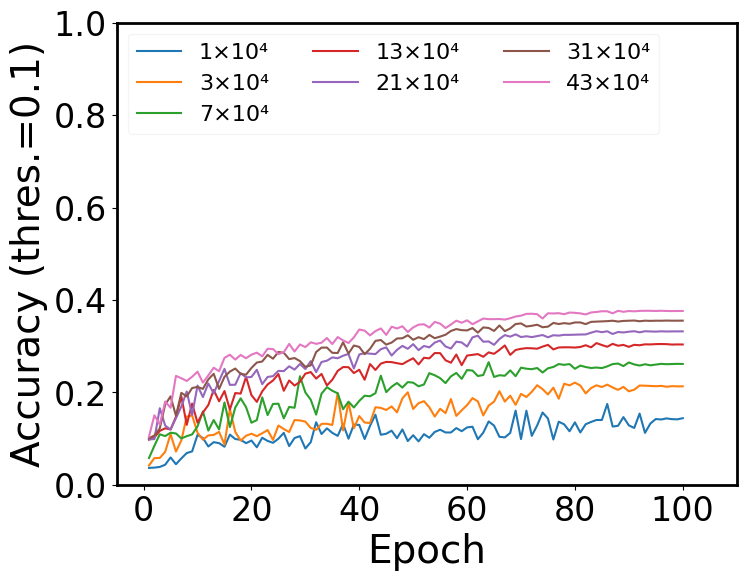

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

num_vae = 10  
num_mappings = [1, 3, 7, 13, 21, 31, 43]
#colors = plt.cm.viridis(np.linspace(0, 1, len(num_mappings)))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

plt.figure(figsize=(8, 6))
for i, num_mapping in enumerate(num_mappings):
    file_path = f'./loss/loss_mapping-{num_vae}-{num_mapping}.txt'
    
    if not os.path.exists(file_path):
        print(f"File doesn't exist: {file_path}")
        continue
    data = np.loadtxt(file_path, delimiter=',', skiprows=1)

    # Epoch 0,TL 1,THL 2,TA1 3,TA2 4,TA3 5,TA4 6,TA5 7,VL 8,VHL 9,VA1 10,VA2 11,VA3 12,VA4 13,VA5 14,Time
    epochs = data[:, 0]
    va1 = data[:, 10] #14 !
    
    plt.plot(epochs, va1, label=f'{num_mapping}×10⁴', color=colors[i], linewidth=1.5)

plt.xlabel('Epoch', fontsize=28)
plt.xlim(-5,110)
plt.xticks([0,20,40,60,80,100],fontsize=24)

plt.ylabel('Accuracy (thres.=0.1)', fontsize=28) # !
plt.ylim(0,1)
plt.yticks([0,0.2,0.4,0.6,0.8,1],fontsize=24)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2) 
    
plt.legend(fontsize=16, loc='upper left', ncol=3, framealpha=0.2)

output_path = f'figures/acc_{num_vae}_1.tiff' # !
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

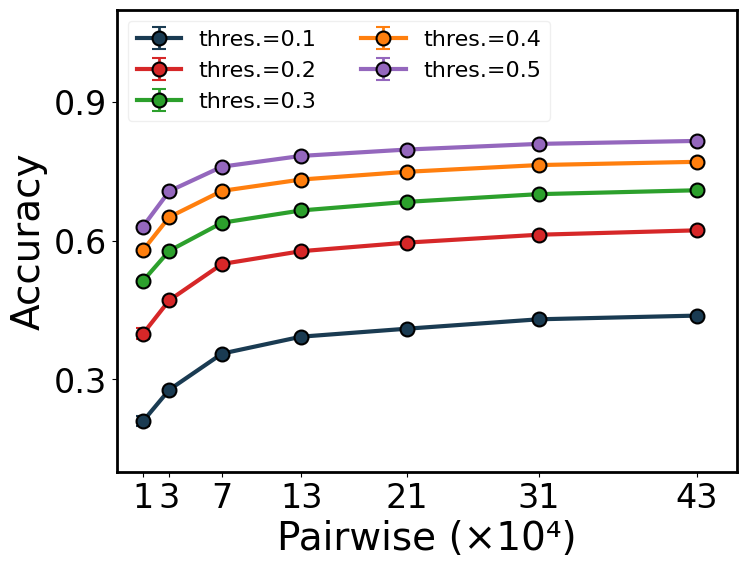

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

num_vae = 2  
num_mappings = [1, 3, 7, 13, 21, 31, 43]

# 存储每个num_mapping对应的VA1-VA5的均值和误差
va_accuracies = {f'VA{i+1}': [] for i in range(5)}  # VA1-VA5
va_errors = {f'VA{i+1}': [] for i in range(5)}

for num_mapping in num_mappings:
    file_path = f'./loss/loss_mapping-{num_vae}-{num_mapping}.txt'
    
    if not os.path.exists(file_path):
        print(f"File doesn't exist: {file_path}")
        for i in range(5):
            va_accuracies[f'VA{i+1}'].append(np.nan)
            va_errors[f'VA{i+1}'].append(np.nan)
        continue
    
    data = np.loadtxt(file_path, delimiter=',', skiprows=1)
    
    # 取最后3个epoch
    last_3_epochs = data[-3:, :]
    
    # VA1-VA5列索引为10,11,12,13,14
    va_columns = last_3_epochs[:, 10:15]  # shape: (3, 5)
    
    # 对于每个VA（每列），计算最后3个epoch的均值和标准差
    for i in range(5):  # i=0对应VA1, i=1对应VA2, etc.
        va_data = va_columns[:, i]  # 取第i列，即VA{i+1}的数据
        mean_va = np.mean(va_data)  # 计算该VA在最后3个epoch的均值
        std_va = np.std(va_data)   # 计算该VA在最后3个epoch的标准差
        
        va_accuracies[f'VA{i+1}'].append(mean_va)
        va_errors[f'VA{i+1}'].append(std_va)

# 转换为numpy数组
num_mappings_arr = np.array(num_mappings)
colors = ['#1a3b52', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']  # 5种不同颜色
labels = ['thres.=0.1', 'thres.=0.2', 'thres.=0.3', 'thres.=0.4', 'thres.=0.5']

plt.figure(figsize=(8, 6))

for i, va_name in enumerate(['VA1', 'VA2', 'VA3', 'VA4', 'VA5']):
    accuracies = np.array(va_accuracies[va_name])
    error_bars = np.array(va_errors[va_name])
    
    plt.errorbar(num_mappings_arr, accuracies, yerr=error_bars, 
                 fmt='o-', linewidth=3, markersize=10, capsize=5, capthick=2,
                 color=colors[i], markerfacecolor=colors[i], 
                 markeredgecolor='black', markeredgewidth=1.5,
                 ecolor=colors[i], elinewidth=2, label=labels[i])

plt.xlabel('Pairwise (×10⁴)', fontsize=28)
plt.xlim(-1,46)
plt.xticks(num_mappings_arr, fontsize=24)

plt.ylabel('Accuracy', fontsize=28)
plt.ylim(0.1, 1.1)
plt.yticks([0.3, 0.6, 0.9], fontsize=24)

# 添加图例
plt.legend(fontsize=16, loc='upper left', ncol=2, framealpha=0.3)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2) 

output_path = f'figures/acc_{num_vae}.tiff'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

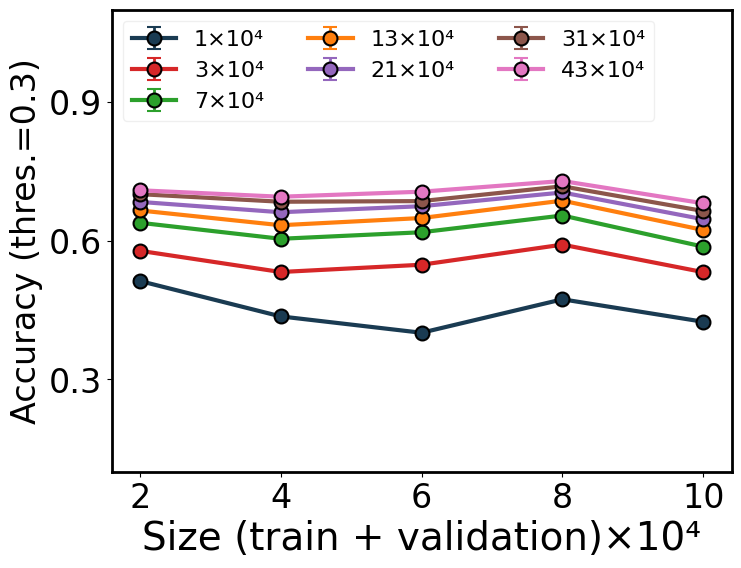

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

num_vaes = [2, 4, 6, 8, 10]  # 不同的num_vae值
num_mappings = [1, 3, 7, 13, 21, 31, 43]  # 7个不同的pairwise值

# 创建数据存储结构：对每个num_mapping存储所有num_vae的准确率
mapping_accuracies = {num_mapping: [] for num_mapping in num_mappings}
mapping_errors = {num_mapping: [] for num_mapping in num_mappings}

for num_mapping in num_mappings:
    for num_vae in num_vaes:
        file_path = f'./loss/loss_mapping-{num_vae}-{num_mapping}.txt'
        
        if not os.path.exists(file_path):
            print(f"File doesn't exist: {file_path}")
            mapping_accuracies[num_mapping].append(np.nan)
            mapping_errors[num_mapping].append(np.nan)
            continue
        
        data = np.loadtxt(file_path, delimiter=',', skiprows=1)
        
        # 取最后3个epoch
        last_3_epochs = data[-3:, :]
        
        # 只取VA5的数据（列索引为14）
        va5_data = last_3_epochs[:, 12]  # VA5列索引为14
        
        mean_acc = np.mean(va5_data)  # 计算VA5在最后3个epoch的均值
        std_acc = np.std(va5_data)    # 计算VA5在最后3个epoch的标准差
        
        mapping_accuracies[num_mapping].append(mean_acc)
        mapping_errors[num_mapping].append(std_acc)

# 转换为numpy数组
num_vae_arr = np.array(num_vaes)
colors = ['#1a3b52', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2']  # 7种不同颜色
labels = [f'{num_mapping}×10⁴' for num_mapping in num_mappings]

plt.figure(figsize=(8, 6))

for i, num_mapping in enumerate(num_mappings):
    accuracies = np.array(mapping_accuracies[num_mapping])
    error_bars = np.array(mapping_errors[num_mapping])
    
    plt.errorbar(num_vae_arr, accuracies, yerr=error_bars, 
                 fmt='o-', linewidth=3, markersize=10, capsize=5, capthick=2,
                 color=colors[i], markerfacecolor=colors[i], 
                 markeredgecolor='black', markeredgewidth=1.5,
                 ecolor=colors[i], elinewidth=2, label=labels[i])

plt.xlabel('Size (train + validation)×10⁴', fontsize=28)
plt.xticks(num_vae_arr, fontsize=24)

plt.ylabel('Accuracy (thres.=0.3)', fontsize=24)
plt.ylim(0.1, 1.1)
plt.yticks([0.3, 0.6, 0.9], fontsize=24)

# 添加图例
plt.legend(fontsize=16, loc='upper left', ncol=3, framealpha=0.3)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2) 

output_path = f'figures/acc_change_by_num_vae_thes3.tiff'
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
plt.close()

In [ ]:
import os
from PIL import Image
import glob

# 确保figures目录存在
figures_dir = 'figures'
if not os.path.exists(figures_dir):
    print(f"目录 {figures_dir} 不存在")
    exit()

# 获取所有tiff/tif文件
tiff_files = glob.glob(os.path.join(figures_dir, '*.tiff')) + glob.glob(os.path.join(figures_dir, '*.tif'))

if not tiff_files:
    print(f"在 {figures_dir} 目录中没有找到TIFF文件")
    exit()

print(f"找到 {len(tiff_files)} 个TIFF文件，开始压缩处理...")

for tiff_file in tiff_files:
    try:
        # 读取原始TIFF图像
        img = Image.open(tiff_file)
        
        # 获取原始文件名和扩展名
        filename = os.path.basename(tiff_file)
        
        # 确保使用.tif扩展名（如果原始是.tiff，也转换为.tif）
        if filename.lower().endswith('.tiff'):
            new_filename = filename[:-5] + '.tif'
        else:
            new_filename = filename
            
        output_path = os.path.join(figures_dir, new_filename)
        
        # 保存为压缩的TIFF格式，保持原始精度
        # 使用LZW压缩（无损压缩），保持图像质量不变
        img.save(output_path, format='TIFF', compression='tiff_lzw', save_all=True)
        
        print(f"成功处理: {filename} -> {new_filename}")
        
    except Exception as e:
        print(f"处理文件 {tiff_file} 时出错: {e}")

print("所有TIFF文件压缩处理完成！")